## ASSIGNMENT 10: Product Performance Analysis

## Q10.1: Profit Calculation
#### Load product data and calculate profit per product (SellingPrice - ManufacturingCost) × UnitsSold

In [2]:
import pandas as pd
df=pd.read_csv('assignment10_product_performance(in).csv')
df

,ProductID,ProductName,Category,UnitsProduced,UnitsSold,ManufacturingCost,SellingPrice,ReturnRate,CustomerSatisfaction,MarketShare,LaunchDate
0,3001,Product_1,Standard,624,1148,362,798,1.58,3.8,4.59,1/1/2020 0:00
1,3002,Product_2,Premium,9179,5123,245,725,9.31,2.3,4.38,1/19/2020 10:40
2,3003,Product_3,Budget,8499,8538,424,590,4.64,3.9,8.03,2/6/2020 21:20
3,3004,Product_4,Standard,248,3837,402,354,1.90,4.3,3.90,2/25/2020 8:00
4,3005,Product_5,Budget,8101,2146,141,480,3.09,3.8,2.29,3/14/2020 18:40
...,...,...,...,...,...,...,...,...,...,...,...
95,3096,Product_96,Premium,8114,4207,485,198,3.30,4.0,14.35,10/18/2024 5:20
96,3097,Product_97,Premium,1703,8561,95,377,8.21,2.6,9.36,11/5/2024 16:00
97,3098,Product_98,Budget,1422,2199,93,662,5.41,4.5,0.52,11/24/2024 2:40
98,3099,Product_99,Budget,6056,6763,327,762,8.61,3.3,13.46,12/12/2024 13:20


In [3]:
df['Profit']=(df['SellingPrice']-df['ManufacturingCost'])*df['UnitsSold']

In [4]:
print("Profit Analysis:")
print(df[['ProductName','UnitsSold','ManufacturingCost','SellingPrice','Profit']].head())

Profit Analysis:
  ProductName  UnitsSold  ManufacturingCost  SellingPrice   Profit
0   Product_1       1148                362           798   500528
1   Product_2       5123                245           725  2459040
2   Product_3       8538                424           590  1417308
3   Product_4       3837                402           354  -184176
4   Product_5       2146                141           480   727494


In [5]:
print(f"\n Profit Calculation: ${df['Profit'].sum():,.2f}")


 Profit Calculation: $146,711,344.00


## Q10.2: Category Filtering
#### Filter products by category and analyze sales performance (UnitsSold vs UnitsProduced).

In [6]:
Filter=df[df['Category']=='Budget']

In [7]:
performance=Filter[['Category','UnitsSold','UnitsProduced','Profit']]
performance.head()

,Category,UnitsSold,UnitsProduced,Profit
2,Budget,8538,8499,1417308
4,Budget,2146,8101,727494
6,Budget,6038,3849,1805362
8,Budget,7219,4553,2598840
11,Budget,8917,2923,-89170


In [8]:
performance = Filter.groupby('Category').agg(UnitsProduced=('UnitsProduced', 'sum'),UnitsSold=('UnitsSold', 'sum')).reset_index()
print("Sales_Performance:")
performance

Sales_Performance:


,Category,UnitsProduced,UnitsSold
0,Budget,207319,181664


In [9]:
comparison=(Filter['UnitsSold']>=Filter['UnitsProduced'])
comparison.head()

2      True
4     False
6      True
8      True
11     True
dtype: bool

In [10]:
sales=((Filter['UnitsSold']/Filter['UnitsProduced'])*100).round(2).reset_index().head()
print("Sales Performance:")
sales

Sales Performance:


,index,0
0,2,100.46
1,4,26.49
2,6,156.87
3,8,158.55
4,11,305.06


## Q10.3: Profitability by Category
#### Group by category and calculate total profit, average profit, and profit margin

In [11]:
df['Revenue']=df['SellingPrice']*df['UnitsSold']
df.head()

,ProductID,ProductName,Category,UnitsProduced,UnitsSold,ManufacturingCost,SellingPrice,ReturnRate,CustomerSatisfaction,MarketShare,LaunchDate,Profit,Revenue
0,3001,Product_1,Standard,624,1148,362,798,1.58,3.8,4.59,1/1/2020 0:00,500528,916104
1,3002,Product_2,Premium,9179,5123,245,725,9.31,2.3,4.38,1/19/2020 10:40,2459040,3714175
2,3003,Product_3,Budget,8499,8538,424,590,4.64,3.9,8.03,2/6/2020 21:20,1417308,5037420
3,3004,Product_4,Standard,248,3837,402,354,1.90,4.3,3.90,2/25/2020 8:00,-184176,1358298
4,3005,Product_5,Budget,8101,2146,141,480,3.09,3.8,2.29,3/14/2020 18:40,727494,1030080


In [12]:
category = df.groupby('Category').agg({'Profit': ['sum', 'mean'],'UnitsSold': 'sum','SellingPrice': 'mean'}).round(2)

In [13]:
category

Profit             UnitsSold SellingPrice
               sum        mean       sum         mean
Category                                             
Budget    54473071  1433501.87    181664       584.34
Premium   45665348  1630905.29    114880       677.11
Standard  46572925  1369791.91    142133       553.94

In [14]:
category = (df.groupby('Category').agg(TotalProfit=('Profit', 'sum'),AverageProfit=('Profit', 'mean'),
           TotalUnitsSold=('UnitsSold', 'sum'),TotalRevenue=('Revenue', 'sum')).round(2))
category

,TotalProfit,AverageProfit,TotalUnitsSold,TotalRevenue
Category,,,,
Budget,54473071,1433501.87,181664,101301016
Premium,45665348,1630905.29,114880,71411541
Standard,46572925,1369791.91,142133,86677708


In [15]:
category['ProfitMargin']=(category['TotalProfit'] / category['TotalRevenue']) * 100
category['ProfitMargin'].reset_index()

,Category,ProfitMargin
0,Budget,53.773470
1,Premium,63.946734
2,Standard,53.731145


## Q10.4: Top 10 Products
#### Identify top 10 products by profit and create bar chart visualization

In [16]:
top_10=df.nlargest(10,'Profit')
top_10

,ProductID,ProductName,Category,UnitsProduced,UnitsSold,ManufacturingCost,SellingPrice,ReturnRate,CustomerSatisfaction,MarketShare,LaunchDate,Profit,Revenue
20,3021,Product_21,Standard,9813,8015,175,995,9.65,4.8,12.64,1/3/2021 21:20,6572300,7974925
59,3060,Product_60,Standard,166,7276,155,964,5.25,4.2,11.08,12/24/2022 5:20,5886284,7014064
92,3093,Product_93,Standard,2100,7389,134,873,1.34,3.8,2.55,8/23/2024 21:20,5460471,6450597
9,3010,Product_10,Standard,5436,6064,147,924,9.33,4.8,1.00,6/15/2020 0:00,4711728,5603136
73,3074,Product_74,Standard,7006,8511,446,997,5.72,4.6,13.29,9/8/2023 10:40,4689561,8485467
68,3069,Product_69,Standard,904,7873,120,650,5.47,4.3,4.55,6/8/2023 5:20,4172690,5117450
49,3050,Product_50,Budget,9357,5412,221,984,7.45,3.6,11.01,6/22/2022 18:40,4129356,5325408
33,3034,Product_34,Budget,4607,5845,111,799,8.03,4.3,10.64,8/31/2021 16:00,4021360,4670155
60,3061,Product_61,Standard,8928,8082,349,846,0.47,4.8,13.39,1/11/2023 16:00,4016754,6837372
86,3087,Product_87,Premium,3718,6583,253,858,3.48,2.7,1.84,5/5/2024 5:20,3982715,5648214


In [18]:
import matplotlib.pyplot as plt

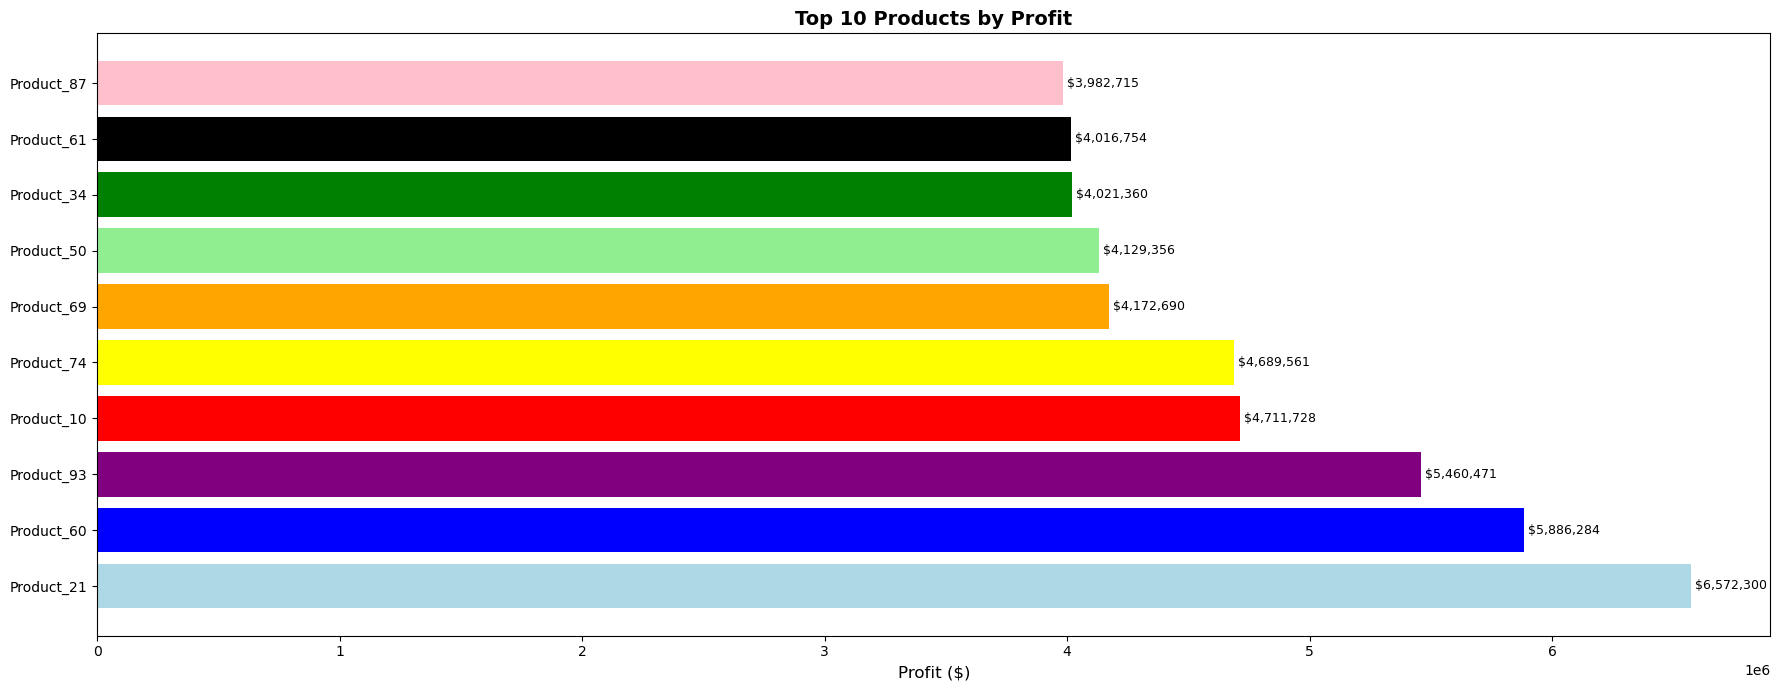

In [37]:
plt.figure(figsize=(18, 7))
colors = ['lightblue', 'blue', 'purple', 'red', 'yellow', 'orange', 'lightgreen', 'green', 'black', 'pink']
plt.barh(range(len(top_10)), top_10['Profit'], color=colors)
plt.yticks(range(len(top_10)), top_10['ProductName'], fontsize=10)
plt.xlabel('Profit ($)', fontsize=12)
plt.title('Top 10 Products by Profit', fontsize=14, fontweight='bold')
for i, v in enumerate(top_10['Profit']):
    plt.text(v, i, f' ${v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Q10.5: Relationship Analysis
#### Analyze correlation between CustomerSatisfaction and ReturnRate using correlation

In [20]:
correlation=df[['CustomerSatisfaction','ReturnRate']]
correlation.corr()

,CustomerSatisfaction,ReturnRate
CustomerSatisfaction,1.000000,-0.069575
ReturnRate,-0.069575,1.000000


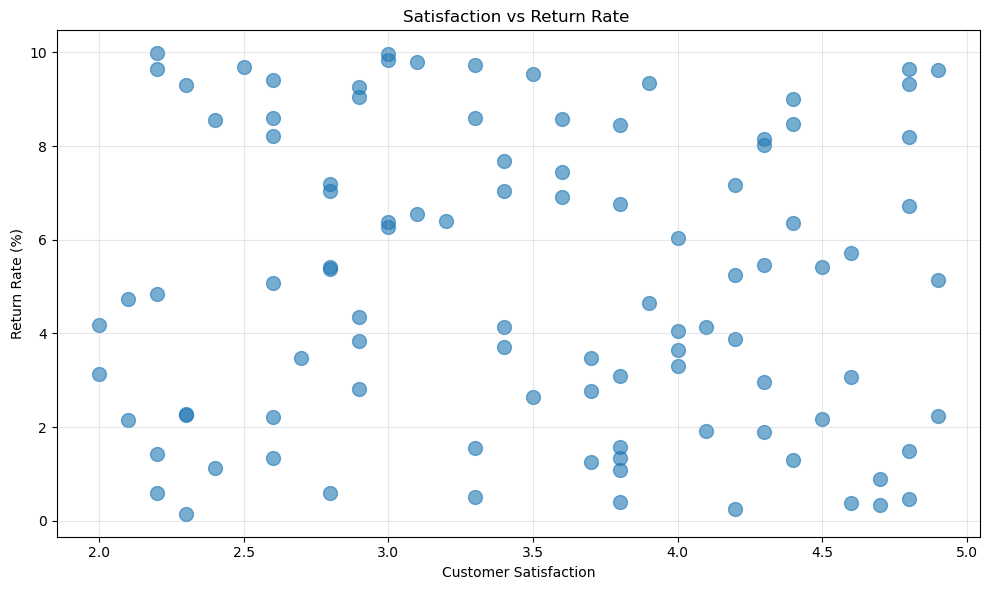

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(df['CustomerSatisfaction'], df['ReturnRate'], alpha=0.6, s=100)
plt.xlabel('Customer Satisfaction')
plt.ylabel('Return Rate (%)')
plt.title(f"Satisfaction vs Return Rate ")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Q10.6: Pivot Analysis
#### Create pivot table showing average profit by category and market share brackets

In [22]:
df['MarketShareBracket']=pd.cut(df['MarketShare'],bins=3,labels=['Low','Medium','High'])

In [23]:
pivot_profit= pd.pivot_table(df,values='Profit',index='Category',columns='MarketShareBracket',aggfunc='mean',observed=True).round(2)
pivot_profit


MarketShareBracket,Low,Medium,High
Category,,,
Budget,1210870.46,1618649.2,1503017.53
Premium,1839296.62,1851629.5,647639.40
Standard,1108464.50,534551.0,2936497.88


## Q10.7: Performance Metrics
#### Add calculated columns: ProfitMargin%, Sellthrough% (UnitsSold/UnitsProduced)

In [32]:
df['ProfitMargin%']=(df['Profit']/df['Revenue'])*100

In [33]:
df['Sellthrough%']=(df['UnitsSold']/df['UnitsProduced'])*100
df.head()

,ProductID,ProductName,Category,UnitsProduced,UnitsSold,ManufacturingCost,SellingPrice,ReturnRate,CustomerSatisfaction,MarketShare,LaunchDate,Profit,Revenue,MarketShareBracket,ProfitMargin,Sellthrough%,ProfitMargin%
0,3001,Product_1,Standard,624,1148,362,798,1.58,3.8,4.59,1/1/2020 0:00,500528,916104,Low,54.636591,183.974359,54.636591
1,3002,Product_2,Premium,9179,5123,245,725,9.31,2.3,4.38,1/19/2020 10:40,2459040,3714175,Low,66.206897,55.812180,66.206897
2,3003,Product_3,Budget,8499,8538,424,590,4.64,3.9,8.03,2/6/2020 21:20,1417308,5037420,Medium,28.135593,100.458878,28.135593
3,3004,Product_4,Standard,248,3837,402,354,1.90,4.3,3.90,2/25/2020 8:00,-184176,1358298,Low,-13.559322,1547.177419,-13.559322
4,3005,Product_5,Budget,8101,2146,141,480,3.09,3.8,2.29,3/14/2020 18:40,727494,1030080,Low,70.625000,26.490557,70.625000


## Q10.8: Ranking Report
#### Export a summary report with product rankings by profitability and performance

In [34]:
ranking_report = (df.sort_values(by='Profit', ascending=False)
      [['ProductName', 'Category', 'Profit', 'ProfitMargin%', 'Sellthrough%', 'CustomerSatisfaction']])

In [35]:
ranking_report.to_csv('product_ranking_report.csv', index=False)

## Q10.9: Multi-visualization Dashboard
#### Create 4 different visualizations: profit by category, satisfaction vs returns, market share, pie chart

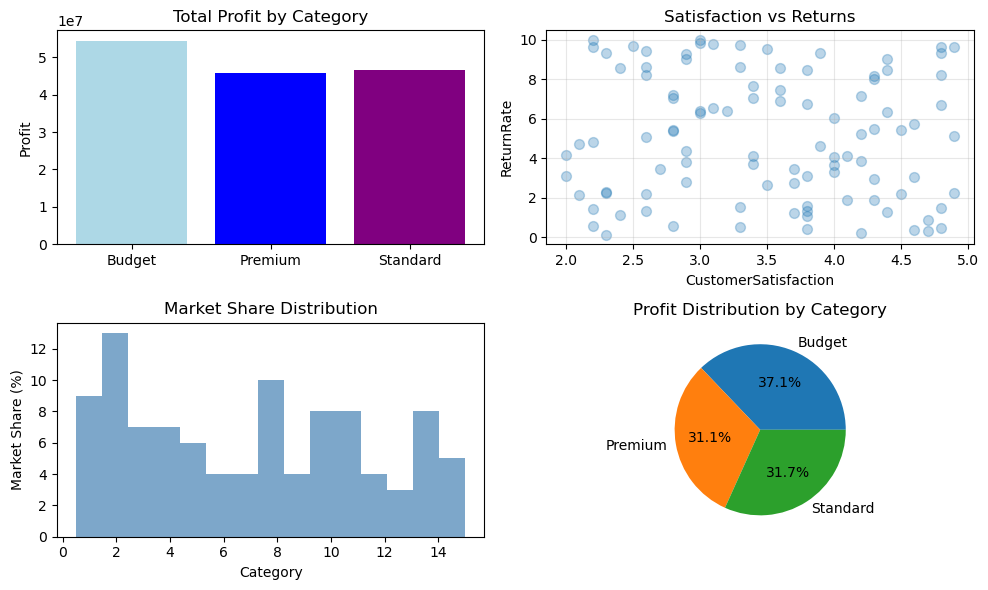

In [49]:
fig,axes=plt.subplots(2,2,figsize=(10,6))
colors = ['lightblue', 'blue', 'purple']
# Profit by Category
category=df.groupby('Category')['Profit'].sum()
axes[0,0].bar(category.index,category.values,color=colors)
axes[0,0].set_title('Total Profit by Category')
axes[0,0].set_ylabel('Profit')
# Satisfaction vs Returns
axes[0,1].scatter(df['CustomerSatisfaction'],df['ReturnRate'],s=50,alpha=0.3)
axes[0,1].set_title('Satisfaction vs Returns')
axes[0,1].set_xlabel('CustomerSatisfaction')
axes[0,1].set_ylabel('ReturnRate') 
axes[0,1].grid(True,alpha=0.3)
# Market share
axes[1, 0].hist(df['MarketShare'], bins=15, color='steelblue', alpha=0.7)
axes[1, 0].set_title('Market Share Distribution')
axes[1, 0].set_ylabel('Market Share (%)')
axes[1, 0].set_xlabel('Category')
#pie chart
axes[1,1].pie(category,labels=category.index,autopct='%1.1f%%')
axes[1, 1].set_title('Profit Distribution by Category')

plt.tight_layout()
plt.show()

## Q10.10: Executive Summary
#### Generate comprehensive insights: best/worst products, opportunities, and recommendations.

In [52]:
print("=== EXECUTIVE SUMMARY: PRODUCT PERFORMANCE ANALYSIS ===\n")

best_product = df.loc[df['Profit'].idxmax()]
worst_product = df.loc[df['Profit'].idxmin()]

print("KEY FINDINGS:")

print(f"\n1.Best Performing Product: {best_product['ProductName']}")
print(f"Profit: ${best_product['Profit']:,.2f}")
print(f"Margin: {best_product['ProfitMargin%']:.1f}%")
print(f"Satisfaction:{best_product['CustomerSatisfaction']}/5.0")

print(f"\n2.Worst Performing Product: {worst_product['ProductName']}")
print(f"Profit:${worst_product['Profit']:,.2f}")
print(f"Margin:{worst_product['ProfitMargin%']:.1f}%")

print("\n3.Category Performance:")
for cat in df['Category'].unique():
    category=df[df['Category'] == cat]
    print(
        f"{cat}: ${category['Profit'].sum():,.0f} total profit "
        f"({len(cat_data)} products)"
    )

high_returns = df[df['ReturnRate'] > df['ReturnRate'].quantile(0.75)]

print(f"\n4.High Return Products ({len(high_returns)} products):")
print(f"Average Return Rate: {high_returns['ReturnRate'].mean():.2f}%")
print("Recommendation: Review quality/customer-product fit")

print("\n5.OVERALL METRICS:")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Average Satisfaction: {df['CustomerSatisfaction'].mean():.2f}/5.0")
print(f"Avg Sellthrough: {df['Sellthrough%'].mean():.1f}%")

=== EXECUTIVE SUMMARY: PRODUCT PERFORMANCE ANALYSIS ===

KEY FINDINGS:

1.Best Performing Product: Product_21
Profit: $6,572,300.00
Margin: 82.4%
Satisfaction:4.8/5.0

2.Worst Performing Product: Product_62
Profit:$-1,380,216.00
Margin:-223.9%

3.Category Performance:
Standard: $46,572,925 total profit (38 products)
Premium: $45,665,348 total profit (38 products)
Budget: $54,473,071 total profit (38 products)

4.High Return Products (25 products):
Average Return Rate: 9.19%
Recommendation: Review quality/customer-product fit

5.OVERALL METRICS:
Total Profit: $146,711,344.00
Average Satisfaction: 3.50/5.0
Avg Sellthrough: 198.7%


In [57]:
best_product = df.loc[df['Profit'].idxmax()]
worst_product = df.loc[df['Profit'].idxmin()]
print(f'Best Product:{best_product['Profit']}')
print(f'Worst Product:{worst_product['Profit']}')

high_performance = df[df['Profit'] >= df['Profit'].mean()]
low_performance = df[df['Profit'] < df['Profit'].mean()]

high_performance

best_product = df.loc[df['Profit'].idxmax()]
worst_product = df.loc[df['Profit'].idxmin()]

print(' Executive Summary ')
print('='*35)
print("Best Product Summary:")
print('='*35)
print(f' Best performing Product:{best_product['ProductName']}')
print(f' Profit of Best Product: {best_product['Profit']:.2f}')
print(f' SellThrough of Best Product: {best_product['Sellthrough%']:.2f}')

print('='*35)
print("Worst Product Summary:")
print('='*35)
print(f' worst performing Product:{worst_product['ProductName']}')
print(f' Profit of Worst Product: {worst_product['Profit']:.2f}')
print(f' SellThrough of Worst Product: {worst_product['Sellthrough%']:.2f}')

print('='*35)
print("Category Summary:")

print('='*35)
for i in df['Category'].unique():
    category = df[df['Category'] == i]
    print(f"{i}: {category['Profit'].sum():,.0f} ")
    
print('='*35)
print("Recommendation:")

print('='*35)
high_returns = df[df['ReturnRate'] > df['ReturnRate'].quantile(0.75)]
print(f"Average Satisfication Rate: {high_returns['CustomerSatisfaction'].mean():.2f}%")
print(f"Recommendation: Review quality/customer fit")
print('='*35)
print("Overall Performance:")
print('='*35)
print(f'Total Profit:{df['Profit'].sum()}')
print(f'Average Profit: {df['Profit'].mean()}')
print(f'Satifications of Products:{df['CustomerSatisfaction'].mean()}')


Best Product:6572300
Worst Product:-1380216
 Executive Summary 
Best Product Summary:
 Best performing Product:Product_21
 Profit of Best Product: 6572300.00
 SellThrough of Best Product: 81.68
Worst Product Summary:
 worst performing Product:Product_62
 Profit of Worst Product: -1380216.00
 SellThrough of Worst Product: 61.22
Category Summary:
Standard: 46,572,925 
Premium: 45,665,348 
Budget: 54,473,071 
Recommendation:
Average Satisfication Rate: 3.35%
Recommendation: Review quality/customer fit
Overall Performance:
Total Profit:146711344
Average Profit: 1467113.44
Satifications of Products:3.498
